In [1]:
##import libraries##
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import healpy as hp

In [2]:
##Read the tif file##
image = tiff.imread('/media/sf_Shared_Ubuntu/MAPS/gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array = np.array(image)



In [3]:
# Define the spherical coordinates#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 128

## Make empty healpix mask and pixel values vector##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)


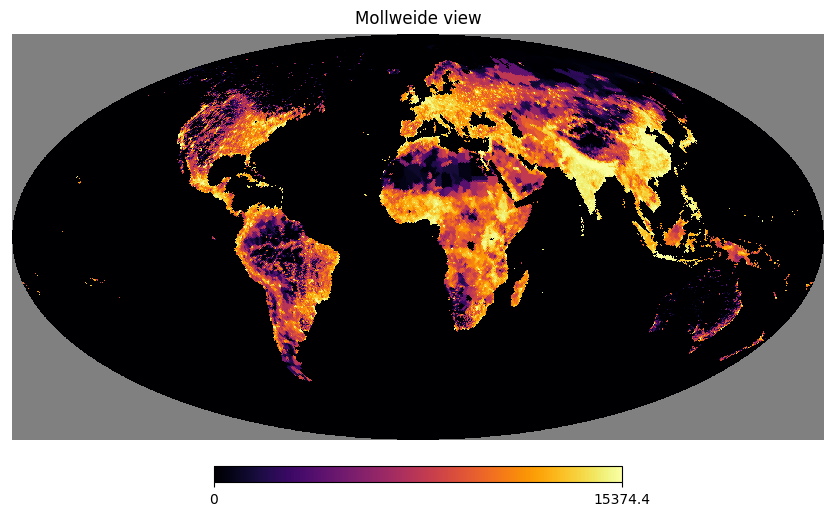

[887 887 887 ... 527 527 527]


In [4]:
for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

# Average value of each pixel#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]


hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()
print(pixel_counts)

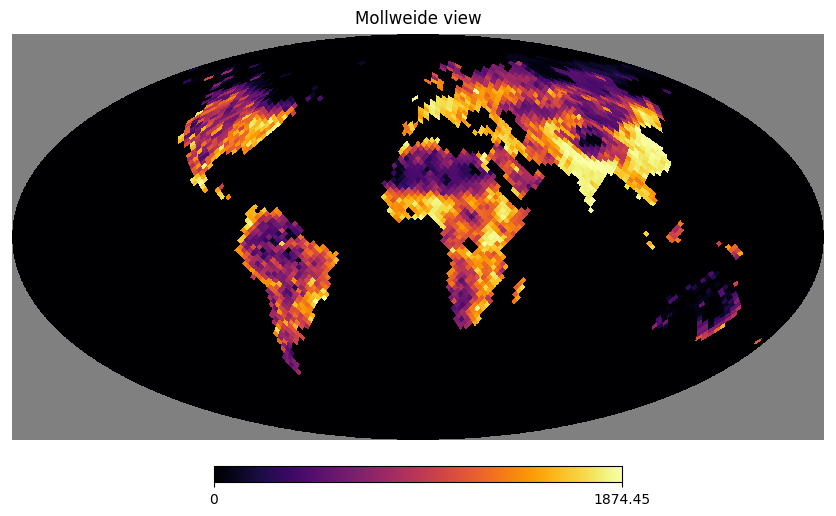

In [5]:
degraded_128=hp.ud_grade(healpix_map,32)
hp.mollview(degraded_128,cmap="inferno", xsize=3000, flip="geo", norm="hist",min=0)

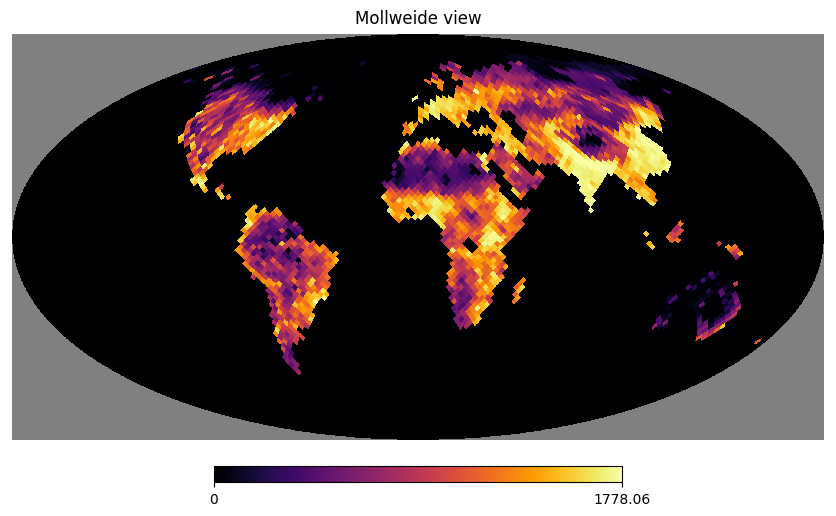

In [6]:
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 32

## Make empty healpix mask and pixel values vector##
healpix_map_32 = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts_32 = np.zeros(hp.nside2npix(nside), dtype=int)
for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map_32[pixel] += image_array[i, j]
        pixel_counts_32[pixel] += 1

# Average value of each pixel#
healpix_map_32[pixel_counts_32>0] /= pixel_counts_32[pixel_counts_32>0 ]


hp.mollview(healpix_map_32, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)

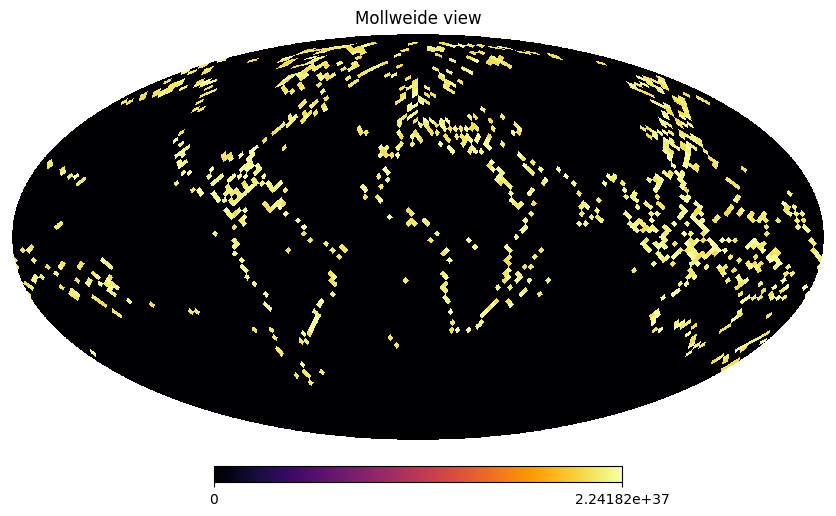

In [7]:
diffmap=healpix_map_32-degraded_128
hp.mollview(diffmap,cmap="inferno", xsize=3000, flip="geo", norm="hist",min=0)

In [8]:
import sys
np.set_printoptions(threshold=sys.maxsize)
print(diffmap)

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -5.67609731e+36  0.00000000e+00 -9.86555856e+36  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -2.21300225e+36
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.17489483e+37
 -8.67392217e+36 -7.65661156e+36 -6.57299142e+36 -4.37252867e+36
 -2.03117950e+36 -6.26526

In [9]:
if np.array_equal(healpix_map_32, degraded_128):
    print('yes')
else:
    print('no')


no


ValueError: shape mismatch: value array of shape (720,1440) could not be broadcast to indexing result of shape (1036800,)

In [23]:
hp.nside2npix(32)

12288